In [46]:
# First, we import the libraries we need
import pandas as pd
import matplotlib.pyplot as plt

# Then we load our dataset
df = pd.read_csv("expenses.csv")

# Just to see if everything loaded correctly, let's look at the first rows
print("Preview of the dataset:")
df.head()

Preview of the dataset:


,Date,Category,Amount
0,2026-03-01,Food,12
1,2026-03-01,Transport,3
2,2026-03-02,Coffee,5
3,2026-03-02,Food,15
4,2026-03-03,Shopping,40


In [47]:
# Here I want to understand the structure of the dataset
# This shows column types and if there are missing values
print("Dataset info:\n")
df.info()

# Quick check for missing values
print("\nMissing values:\n")
print(df.isnull().sum())

Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      58 non-null     object
 1   Category  58 non-null     object
 2   Amount    58 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.5+ KB

Missing values:

Date        0
Category    0
Amount      0
dtype: int64


In [48]:
# Now I clean the data a bit to make sure everything is in the correct format

# Convert Amount column to float (just in case it's read as text)
df["Amount"] = df["Amount"].astype(float)

# Convert Date column into proper datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Remove duplicate rows if there are any
df = df.drop_duplicates()

print("\nData cleaned successfully.")


Data cleaned successfully.


In [49]:
# Now I start with some basic analysis

# Total amount spent
total_spending = df["Amount"].sum()
print("Total Spending:", total_spending, "€")

# Spending by category
category_spending = df.groupby("Category")["Amount"].sum()
print("\nSpending by Category:\n")
print(category_spending)

# Which category I spent the most on
top_category = category_spending.idxmax()
print("\nTop Spending Category:", top_category)

Total Spending: 812.0 €

Spending by Category:

Category
Coffee            62.0
Entertainment    147.0
Food             269.0
Shopping         305.0
Transport         29.0
Name: Amount, dtype: float64

Top Spending Category: Shopping


In [50]:
# Let's look at spending over time

# Daily spending
daily_spending = df.groupby("Date")["Amount"].sum()

# Day with highest spending
most_expensive_day = daily_spending.idxmax()
print("\nMost Expensive Day:", most_expensive_day)

# Average daily spending
average_spending = daily_spending.mean()
print("Average Daily Spending:", round(average_spending, 2), "€")

# Highest single expense
max_transaction = df.loc[df["Amount"].idxmax()]
print("\nHighest Single Expense:\n")
print(max_transaction)


Most Expensive Day: 2026-03-30 00:00:00
Average Daily Spending: 27.07 €

Highest Single Expense:

Date        2026-03-20 00:00:00
Category               Shopping
Amount                     45.0
Name: 37, dtype: object


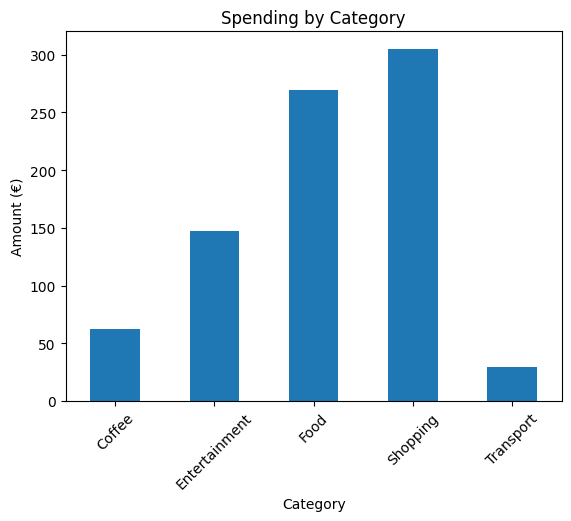

In [51]:
# First visualization: bar chart
# This helps to compare spending across categories

plt.figure()

category_spending.plot(kind="bar")

plt.title("Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount (€)")
plt.xticks(rotation=45)

plt.show()

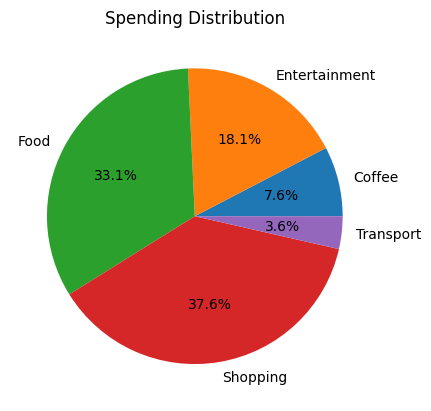

In [52]:
# Pie chart to see the percentage distribution

plt.figure()

category_spending.plot(kind="pie", autopct="%1.1f%%")

plt.title("Spending Distribution")
plt.ylabel("")  # remove default label

plt.show()

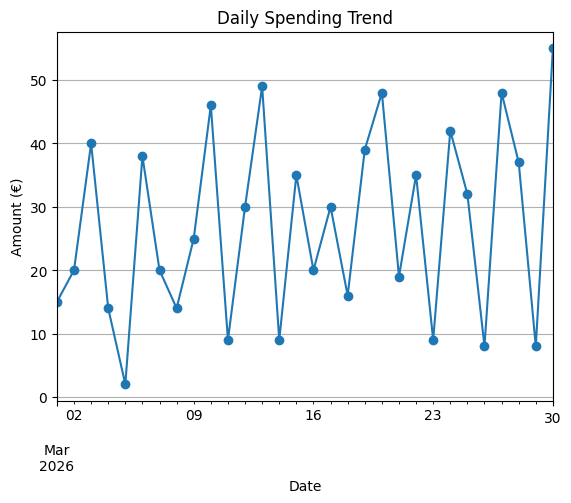

In [53]:
# Line chart to see how spending changes over time

plt.figure()

daily_spending.plot(kind="line", marker="o")

plt.title("Daily Spending Trend")
plt.xlabel("Date")
plt.ylabel("Amount (€)")

plt.grid()

plt.show()

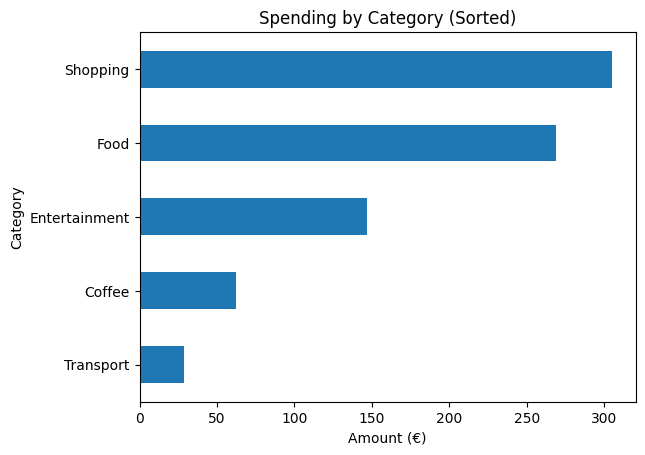

In [54]:
# Sorted bar chart (more professional)

plt.figure()

category_spending.sort_values().plot(kind="barh")

plt.title("Spending by Category (Sorted)")
plt.xlabel("Amount (€)")

plt.show()

Conclusion

The analysis shows that food and shopping are the highest spending categories.  
Daily spending patterns also reveal fluctuations depending on activity levels.